In [6]:
import numpy as np
import sep

In [7]:
# additional setup for reading the test image and displaying plots
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [12]:
hdul = fits.open("./input.fits")
data = hdul[0].data.astype(data.dtype.newbyteorder('='))

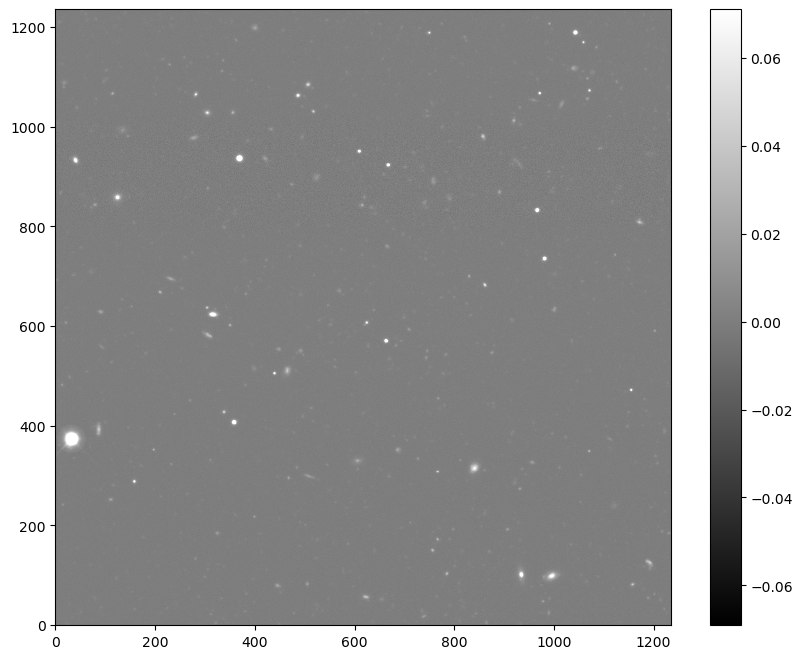

In [13]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [14]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

In [16]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)


0.00012175464507890865
0.0007679372793063521


In [17]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

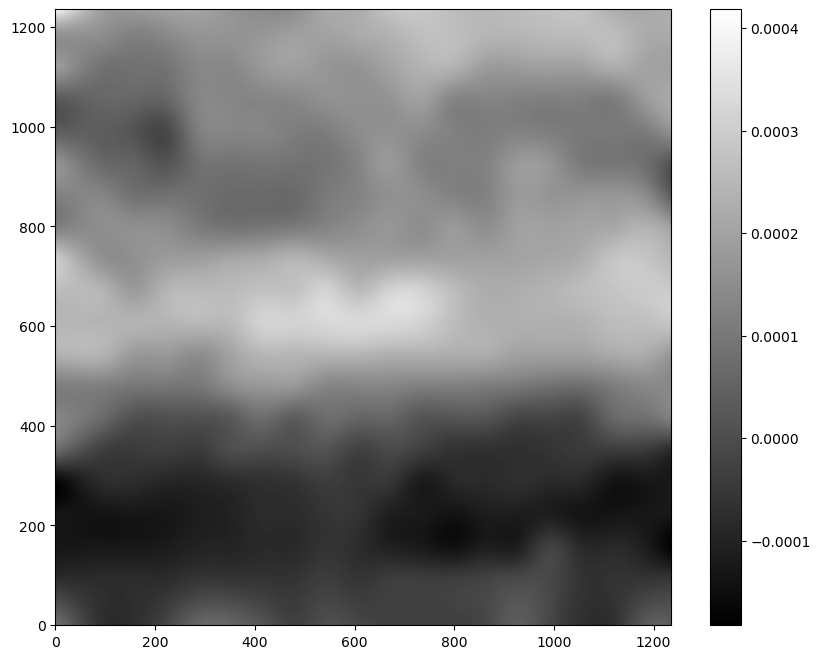

In [18]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [19]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

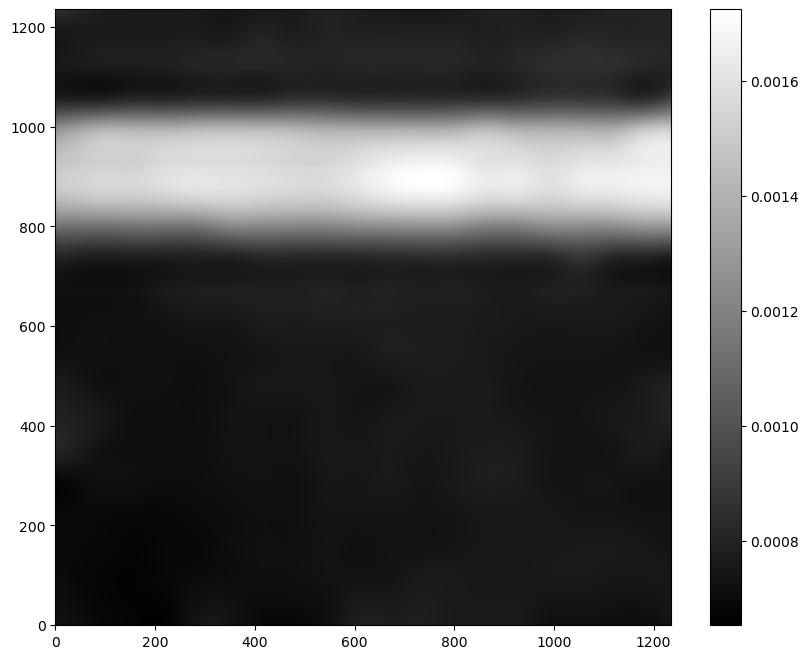

In [20]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [21]:
# subtract the background
data_sub = data - bkg


In [22]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [23]:
# how many objects were detected
len(objects)


1717

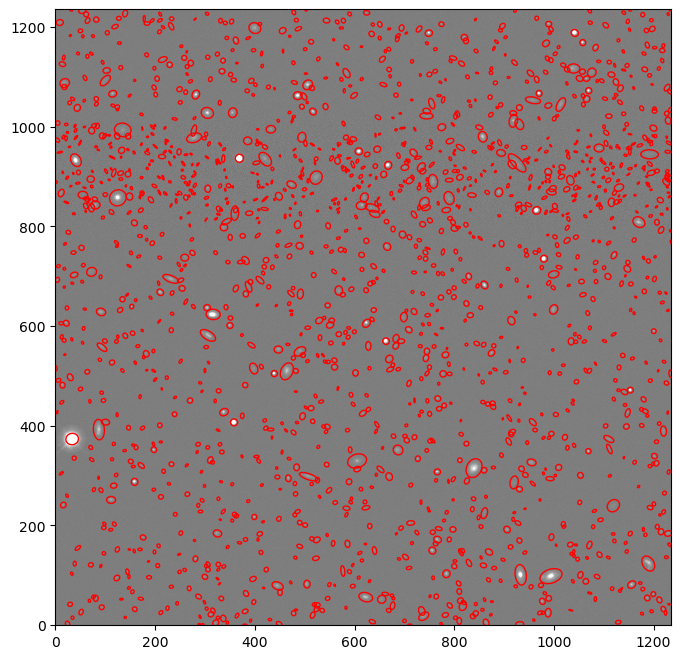

In [24]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)


In [25]:
# available fields
objects.dtype.names


('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [26]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [27]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.024054 +/- 0.155131
object 1: flux = 0.031816 +/- 0.178405
object 2: flux = 0.023258 +/- 0.152547
object 3: flux = 0.025751 +/- 0.160517
object 4: flux = 0.031748 +/- 0.178224
object 5: flux = 0.067693 +/- 0.260212
object 6: flux = 0.033934 +/- 0.184258
object 7: flux = 0.107151 +/- 0.327365
object 8: flux = 0.095532 +/- 0.309108
object 9: flux = 0.045088 +/- 0.212378
